Iteration 1, loss = 1.75527715
Iteration 2, loss = 1.45837190
Iteration 3, loss = 1.36099286
Iteration 4, loss = 1.30265140
Iteration 5, loss = 1.26787589
Iteration 6, loss = 1.23597962
Iteration 7, loss = 1.21642760
Iteration 8, loss = 1.19500427
Iteration 9, loss = 1.18233034
Iteration 10, loss = 1.17681390
Iteration 11, loss = 1.17290518
Iteration 12, loss = 1.15942008
Iteration 13, loss = 1.12711209
Iteration 14, loss = 1.12353146
Iteration 15, loss = 1.11714593
Iteration 16, loss = 1.09708391
Iteration 17, loss = 1.08903954
Iteration 18, loss = 1.07891823
Iteration 19, loss = 1.06659044
Iteration 20, loss = 1.05577711
Iteration 21, loss = 1.03476255
Iteration 22, loss = 1.03098886
Iteration 23, loss = 1.01403821
Iteration 24, loss = 1.00425787
Iteration 25, loss = 0.99137298
Iteration 26, loss = 0.97479479
Iteration 27, loss = 0.97210564
Iteration 28, loss = 0.97493174
Iteration 29, loss = 0.95786576
Iteration 30, loss = 0.94022291
Iteration 31, loss = 0.93362937
Iteration 32, los

c:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


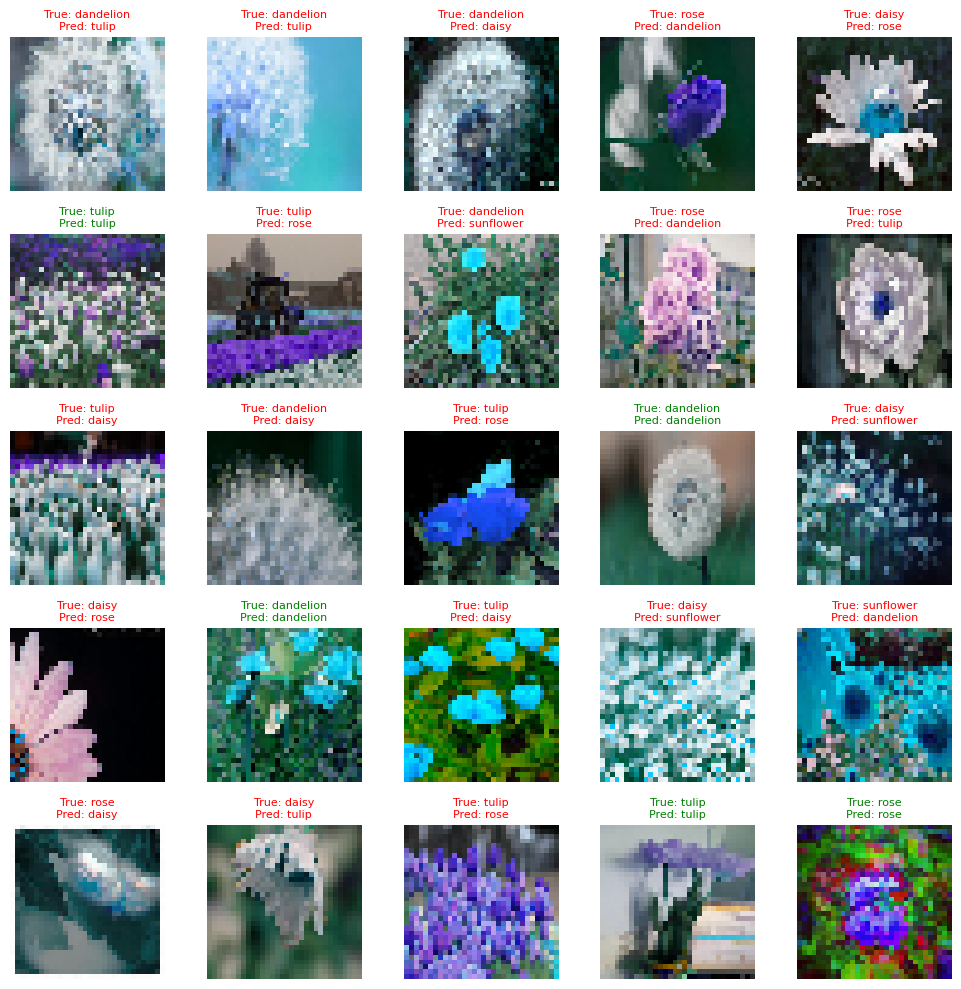

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score

# Load Dataset & Preprocessing
dataset_path = '.' 
categories = ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']
img_size = 32

data = []
labels = []

for category in categories:
    path = os.path.join(dataset_path, category)
    class_index = categories.index(category)
    if not os.path.exists(path):
        continue
    for img_name in os.listdir(path):
        try:
            img_path = os.path.join(path, img_name)
            img_arr = cv2.imread(img_path)
            if img_arr is not None:
                resized_img = cv2.resize(img_arr, (img_size, img_size))
                data.append(resized_img)
                labels.append(class_index)
        except Exception as e:
            pass

X = np.array(data)
y = np.array(labels)
X = X / 255.0
X_flattened = X.reshape(X.shape[0], -1)

# Split Data (Ganti angka di random_state dengan NIM Anda)[cite: 1]
NIM_RANDOM_STATE = 12345678  
X_train, X_test, y_train, y_test = train_test_split(
    X_flattened, y, test_size=0.2, random_state=NIM_RANDOM_STATE
)

# Training Model MLP
mlp_model = MLPClassifier(
    hidden_layer_sizes=(50,), 
    activation='relu', 
    solver='adam', 
    max_iter=200, 
    random_state=NIM_RANDOM_STATE,
    verbose=True
)
mlp_model.fit(X_train, y_train)

# Evaluasi & Classification Report[cite: 1]
y_pred = mlp_model.predict(X_test)
print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred, target_names=categories, digits=4))
print(f"Akurasi Model: {accuracy_score(y_test, y_pred) * 100:.2f}%")

# Visualisasi 25 Gambar Prediksi[cite: 1]
fig, axes = plt.subplots(5, 5, figsize=(10, 10))
axes = axes.flatten()
random_indices = random.sample(range(len(X_test)), min(25, len(X_test)))

for i, idx in enumerate(random_indices):
    img = X_test[idx].reshape(img_size, img_size, 3)
    true_label = categories[y_test[idx]]
    pred_label = categories[y_pred[idx]]
    
    axes[i].imshow(img)
    color = 'green' if true_label == pred_label else 'red'
    axes[i].set_title(f"True: {true_label}\nPred: {pred_label}", color=color, fontsize=8)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# UAS Pengolahan Citra Digital
* **Nama:** [Ikhwanul Fitra]
* **NIM:** [24146033]